# Does resetting recurrent state every three seconds change this model's results?

This is an **evaluation of an existing checkpoint**, not a retraining experiment. Run all cells in order using the repository's `.venv` Python kernel. It works from the repository root or `notebooks_analysis/`. All outputs and plots are saved in this notebook for inspection. Numerical results are also exported to `notebooks_analysis/results/state_reset_<checkpoint-directory>_<checkpoint-stem>/`.

## Experimental design
1. Reproduce `train.evaluate()` on the **exact cropped/padded 300-frame Dataset** and compare with checkpoint metadata. Both train and validation data are evaluated with frozen weights, no augmentation, `model.eval()` and no gradients.
2. Run a **paired 2×2 ablation on every original frame** of each recording. Reset state between files, never carry state between subjects or recordings. The same high-pass-filtered samples, labels, thresholds and event postprocessing are used in every arm.

| Arm | CNN history at a segment boundary | GRU state at a segment boundary |
|---|---|---|
| `reset_both` | Reset | Reset |
| `carry_gru_only` | Reset | Carry |
| `carry_cnn_only` | Carry | Reset |
| `continuous` | Carry | Carry |

**Main contrast:** `continuous − reset_both`. **GRU-only contrasts:** `carry_gru_only − reset_both` and `continuous − carry_cnn_only`. This avoids blaming convolutional boundary padding on recurrent memory.

The existing Dataset fits each collection segment to 300 frames. Actual segment lengths are not always 300. The main paired experiment retains **all real frames, no padding or cropping**. Therefore `reset_both` is the same reset policy, but not literally the exact Dataset reference. We report both and quantify this distinction.

### Continuous reference and `step()` equivalence
Continuous inference here means the checkpoint's causal `forward()` over a full recording, verified against independent single-frame and chunked `step()` inference. The state-reset arms use the same streaming-equivalent computation. This notebook does not modify model code or checkpoint weights.


In [1]:
from pathlib import Path
import sys, json, platform, subprocess, hashlib, importlib.metadata
from datetime import datetime, timezone

ROOT = Path.cwd().resolve()
if not (ROOT / 'tap_recognition').is_dir():
    ROOT = ROOT.parent
assert (ROOT / 'tap_recognition').is_dir(), 'Start from the repo root or notebooks/'
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'notebooks'))
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from torch.utils.data import DataLoader
from tap_recognition.model import CausalCNNGRU
from tap_recognition.config import TrainConfig, DataConfig, LabelConfig
from train import build_datasets, evaluate
from state_reset_analysis import (
    MODES, sha256, load_recordings, numerical_checks, check_event_matching,
    predict_modes, score_recording, summarize, aggregate, paired_bootstrap, event_counts,
)
%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .2})
pd.set_option('display.max_columns', 30)
pd.set_option('display.precision', 5)

# Change this path to evaluate another checkpoint; do not select it on these results.
CHECKPOINT = ROOT / 'checkpoints/best.pt'
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(1)  # Reproducible CPU run, efficient for this small GRU.
torch.use_deterministic_algorithms(True)
checkpoint_hash_before = sha256(CHECKPOINT)
checkpoint = torch.load(CHECKPOINT, map_location='cpu', weights_only=False)
model = CausalCNNGRU(**checkpoint['model_config']).eval()
model.load_state_dict(checkpoint['model_state'])
train_config = checkpoint['train_config']
settings = {
    'threshold': train_config['training']['prediction_threshold'],
    'event_loss_weight': train_config['training']['event_loss_weight'],
    'neg_window_weight': train_config['training'].get('neg_window_weight', 2.0),
    'tolerance_sec': .15,  # Fixed before examining predictions. Sensitivity analysis below.
    'look_ahead_sec': .12, 'refractory_sec': .50,
}
OUT = ROOT / 'notebooks_analysis/results' / f'state_reset_{CHECKPOINT.parent.name}_{CHECKPOINT.stem}'
OUT.mkdir(parents=True, exist_ok=True)
print('Checkpoint:', CHECKPOINT.relative_to(ROOT), 'epoch:', checkpoint.get('epoch'))
print('SHA256:', sha256(CHECKPOINT))
print('Device: CPU; eval mode; gradients disabled during inference; no training')
print('Settings:', settings)
print('Saved validation metrics:', checkpoint.get('val_metrics'))
display(pd.json_normalize(train_config).T.rename(columns={0: 'checkpoint configuration'}))


Checkpoint: checkpoints/best.pt epoch: 5
SHA256: dca066485d710ff5700c145c2c1736ccf2bf538cd8b499f04bc2e3ea768837ed
Device: CPU; eval mode; gradients disabled during inference; no training
Settings: {'threshold': 0.5, 'event_loss_weight': 15.0, 'neg_window_weight': 1.5, 'tolerance_sec': 0.15, 'look_ahead_sec': 0.12, 'refractory_sec': 0.5}
Saved validation metrics: {'loss': 0.14620963524688374, 'frame_acc': 0.9817121212121213, 'window_acc': 0.8772727272727273, 'precision': 0.7476635513319941, 'recall': 0.9999999998750001, 'tp': 80, 'fp': 27, 'fn': 0, 'tn': 113}


,checkpoint configuration
seed,42
device,auto
out_dir,checkpoints
init_checkpoint,checkpoints/best_pre_finetune.pt
freeze_except_last,False
data.mode,recorded
data.train_dir,data/train_data
data.val_dir,data/valid_data
data.window_samples,300
data.sample_rate,100.0


## 1. Continuity and sample-count audit
Check every timestamp, not just segment labels. Non-monotonic or non-uniform timestamps cause a failure rather than silently pretending a gapped file is continuous. Sparse sidecars are required; missing labels are not treated as negatives. Expected event count and side are asserted per segment.

The high-pass filter runs **once over the whole file** in every arm, exactly as in `RecordedIMUDataset`. It is not reset every segment, and it is not applied twice.


In [2]:
recordings, audit_df, data_manifest = load_recordings(
    ROOT, train_config['data'], train_config['labels']['half_frames']
)
display(audit_df.groupby('split').agg(
    recordings=('file', 'size'), frames=('frames', 'sum'), minutes=('minutes', 'sum'),
    segments=('segments', 'sum'), events=('events', 'sum'),
    min_segment_frames=('segment_min', 'min'), max_segment_frames=('segment_max', 'max'),
    dropped_by_existing_fit=('dropped_by_300_fit', 'sum'),
    padded_by_existing_fit=('padded_by_300_fit', 'sum'),
    min_dt_ms=('min_dt_ms', 'min'), max_dt_ms=('max_dt_ms', 'max'),
))
display(audit_df.groupby(['split', 'action']).agg(files=('file', 'size'), events=('events', 'sum')))
print('All recordings passed strict timestamp, label, and segment checks.')


,recordings,frames,minutes,segments,events,min_segment_frames,max_segment_frames,dropped_by_existing_fit,padded_by_existing_fit,min_dt_ms,max_dt_ms
split,,,,,,,,,,,
train,35,211828,35.30467,700,440,298,305,1844,16,10.0,10.0
valid,11,66601,11.10017,220,80,299,307,605,4,10.0,10.0


files  events
split action                          
train adjust_grip            2       0
      arbitrary              2       0
      knock_once             3       0
      knock_twice_left      11     220
      knock_twice_right     11     220
      pick_place             2       0
      shake_phone            3       0
      switch_hand            1       0
valid adjust_grip            1       0
      arbitrary              1       0
      knock_once             1       0
      knock_twice_left       1      20
      knock_twice_right      3      60
      pick_place             1       0
      shake_phone            2       0
      switch_hand            1       0

All recordings passed strict timestamp, label, and segment checks.


## 2. Reproduce the existing evaluation exactly
This is the original 300-frame Dataset and `train.evaluate()`, using the checkpoint's saved configuration. `precision`/`recall` here collapse left/right into a binary positive class; `window_acc` requires the correct side. The train split is evaluated without augmentation. These are descriptive in-sample train scores, not estimates of generalization.


In [3]:
cfg = TrainConfig()
cfg.seed = train_config['seed']
cfg.data = DataConfig(**train_config['data'])
cfg.labels = LabelConfig(**train_config['labels'])
for key in ('train_dir', 'val_dir'):
    setattr(cfg.data, key, ','.join(str(ROOT / p.strip()) for p in getattr(cfg.data, key).split(',')))
train_ds, valid_ds = build_datasets(cfg)
legacy_rows = []
for split, ds in [('train', train_ds), ('valid', valid_ds)]:
    metrics = evaluate(
        model, DataLoader(ds, batch_size=16, shuffle=False, num_workers=0),
        torch.device('cpu'), settings['threshold'], settings['event_loss_weight'],
        settings['neg_window_weight'],
    )
    legacy_rows.append({'split': split, 'windows': len(ds), **metrics})
legacy_df = pd.DataFrame(legacy_rows).set_index('split')
display(legacy_df)
stored_metrics = checkpoint.get('val_metrics', {})
metadata_comparison = pd.DataFrame([
    {'metric': key, 'saved': value, 'recomputed': legacy_df.loc['valid', key],
     'difference': legacy_df.loc['valid', key] - value}
    for key, value in stored_metrics.items() if key in legacy_df.columns
])
display(metadata_comparison)
# A discrepancy is reported, not hidden: alternate checkpoints may use other data.
print('Stored metrics reproduced within 1e-5:', bool(
    len(metadata_comparison) and metadata_comparison.difference.abs().max() < 1e-5
))


Train dirs:
  /home/aprohack/desktop/work/tap-project/project/tapRecognitionRui/TapRecognition/data/train_data


Val dirs:
  /home/aprohack/desktop/work/tap-project/project/tapRecognitionRui/TapRecognition/data/valid_data


,windows,loss,frame_acc,window_acc,precision,recall,tp,fp,fn,tn
split,,,,,,,,,,
train,700,0.25469,0.97370,0.84857,0.83903,0.94773,417,80,23,180
valid,220,0.14621,0.98171,0.87727,0.74766,1.00000,80,27,0,113


,metric,saved,recomputed,difference
0,loss,0.14621,0.14621,-9.48256e-10
1,frame_acc,0.98171,0.98171,0.00000e+00
2,window_acc,0.87727,0.87727,0.00000e+00
3,precision,0.74766,0.74766,0.00000e+00
4,recall,1.00000,1.00000,0.00000e+00
5,tp,80.00000,80.00000,0.00000e+00
6,fp,27.00000,27.00000,0.00000e+00
7,fn,0.00000,0.00000,0.00000e+00
8,tn,113.00000,113.00000,0.00000e+00


Stored metrics reproduced within 1e-5: True


## 3. Verify that the comparison measures state policy, not a streaming bug
The independent streaming reference retains the last 28 real input frames for CNN context and feeds only **new** CNN outputs into the GRU. Tests use real positive and negative signals, chunk lengths 1, 7, 53 and 300, and a future-input perturbation. BatchNorm is frozen in eval mode.

During the full experiment, every recording also asserts: (a) continuous chunked GRU equals full `forward()`; (b) reset mode equals independent `forward()` calls; (c) the first segment agrees in all four arms. The event matcher has regression checks for duplicates, wrong sides, tolerance boundaries, empty sets and ambiguous matches.


In [4]:
print(check_event_matching())
# Oracle labels must yield exactly the annotated events through the same picker/matcher.
for rec in recordings:
    oracle, _ = event_counts(rec, rec.labels, settings['threshold'], settings['tolerance_sec'],
                             settings['look_ahead_sec'], settings['refractory_sec'])
    assert oracle['event_tp'] == len(rec.events)
    assert oracle['event_fp'] == oracle['event_fn'] == 0
print(f'Oracle event recovery passed on all {len(recordings)} recordings.')
numerical_df = numerical_checks(model, recordings)
display(numerical_df)
print('Equivalence assertions passed. Existing step() differences are diagnostic only.')


8 event-matching regression assertions passed
Oracle event recovery passed on all 46 recordings.


,file,check,max_logit_error,passed,max_probability_error,mean_probability_error
0,imu_CC_knock_twice_left_20260901_153013.csv,"correct streaming, chunk=1",1.43051e-06,True,NaN,NaN
1,imu_CC_knock_twice_left_20260901_153013.csv,"correct streaming, chunk=7",1.31130e-06,True,NaN,NaN
2,imu_CC_knock_twice_left_20260901_153013.csv,"correct streaming, chunk=53",1.43051e-06,True,NaN,NaN
3,imu_CC_knock_twice_left_20260901_153013.csv,"correct streaming, chunk=300",1.43051e-06,True,NaN,NaN
4,imu_CC_knock_twice_left_20260901_153013.csv,future perturbation,0.00000e+00,True,NaN,NaN
5,imu_CC_knock_twice_left_20260901_153013.csv,existing step() diagnostic (not an equivalence...,NaN,NaN,0.26205,0.00432
6,imu_CC_arbitrary_20260901_154914.csv,"correct streaming, chunk=1",1.84774e-06,True,NaN,NaN
7,imu_CC_arbitrary_20260901_154914.csv,"correct streaming, chunk=7",1.66893e-06,True,NaN,NaN
8,imu_CC_arbitrary_20260901_154914.csv,"correct streaming, chunk=53",1.72853e-06,True,NaN,NaN
9,imu_CC_arbitrary_20260901_154914.csv,"correct streaming, chunk=300",1.78814e-06,True,NaN,NaN


Equivalence assertions passed. Existing step() differences are diagnostic only.


## 4. Run the paired experiment
**Window metrics:** use original segment boundaries, maximum left/right probability and the same threshold/loss as `train.py`. Only CNN/GRU boundary policies vary.

**Event metrics:** apply the same `pick_tap_events()` once to the full probability sequence in every arm. Its look-ahead is 120 ms, refractory period 500 ms, one frame above threshold is sufficient, and the optional physical-prior filter is disabled. Postprocessing does not reset at segment boundaries. Match predictions one-to-one with labels within ±150 ms, first maximizing matches, then minimizing timing error. Main event metrics require the correct side: a wrong side is FP + FN. Binary event metrics are also retained. Extra/duplicate alerts count as FP.

Peak timing error is **not deployment emission latency**: `pick_tap_events()` backdates detections to a peak and can flush an incomplete look-ahead at EOF. False positives per minute use actual observed minutes, not an extrapolation to hours of ordinary phone use.


In [5]:
file_rows, segment_rows, event_rows, boundary_rows = [], [], [], []
predictions = {}  # key=(split, filename); arrays remain available for custom inspection.
for recording_index, rec in enumerate(recordings):
    logits, hidden = predict_modes(model, rec)
    probs = {mode: values.softmax(-1).numpy() for mode, values in logits.items()}
    predictions[(rec.split, rec.path.name)] = {'probs': probs, 'hidden': hidden}
    for mode in MODES:
        row, segments, events = score_recording(rec, mode, logits[mode], settings)
        file_rows.append(row)
        segment_rows.extend(segments)
        event_rows.extend(dict(split=rec.split, file=rec.path.name, mode=mode, **e) for e in events)
    contrasts = {
        'total': ('reset_both', 'continuous'),
        'GRU with continuous CNN': ('carry_cnn_only', 'continuous'),
        'GRU with reset CNN': ('reset_both', 'carry_gru_only'),
    }
    for name, (before, after) in contrasts.items():
        difference = np.abs(probs[after] - probs[before]).max(axis=1)
        for i, (a, b) in enumerate(rec.bounds):
            for offset in range(0, b - a, 10):
                values = difference[a + offset:min(a + offset + 10, b)]
                boundary_rows.append(dict(
                    split=rec.split, file=rec.path.name, segment=i + 1, contrast=name,
                    seconds_from_boundary=offset / rec.fs, mean_delta=float(values.mean()),
                    max_delta=float(values.max()),
                ))
    if (recording_index + 1) % 10 == 0 or recording_index + 1 == len(recordings):
        print(f'Evaluated {recording_index + 1}/{len(recordings)} recordings in all four modes')
file_df = pd.DataFrame(file_rows)
segment_df = pd.DataFrame(segment_rows)
event_df = pd.DataFrame(event_rows)
boundary_df = pd.DataFrame(boundary_rows)
summary_df = summarize(file_df)
display(summary_df[['split', 'mode', 'window_acc', 'frame_acc', 'loss', 'window_fp',
                    'event_precision', 'event_recall', 'event_f1', 'event_tp', 'event_fp',
                    'event_fn', 'negative_fp_per_min', 'matched_peak_mae_ms']])
raw_reset = summary_df[summary_df['mode'].eq('reset_both')].set_index('split')
display(pd.DataFrame({
    'exact_300_window_acc': legacy_df.window_acc, 'raw_segment_reset_acc': raw_reset.window_acc,
    'exact_300_loss': legacy_df.loss, 'raw_segment_reset_loss': raw_reset.loss,
}))


Evaluated 10/46 recordings in all four modes


Evaluated 20/46 recordings in all four modes


Evaluated 30/46 recordings in all four modes


Evaluated 40/46 recordings in all four modes


Evaluated 46/46 recordings in all four modes


,split,mode,window_acc,frame_acc,loss,window_fp,event_precision,event_recall,event_f1,event_tp,event_fp,event_fn,negative_fp_per_min,matched_peak_mae_ms
0,train,reset_both,0.84857,0.97392,0.25265,80.0,0.80677,0.92045,0.85987,405.0,97.0,35.0,6.40431,34.54321
1,train,carry_gru_only,0.85143,0.97400,0.25183,78.0,0.81000,0.92045,0.86170,405.0,95.0,35.0,6.25183,34.54321
2,train,carry_cnn_only,0.85286,0.97395,0.25669,77.0,0.81162,0.92045,0.86262,405.0,94.0,35.0,6.17558,34.54321
3,train,continuous,0.85286,0.97398,0.25214,77.0,0.81162,0.92045,0.86262,405.0,94.0,35.0,6.17558,34.54321
4,valid,reset_both,0.87727,0.98188,0.14485,27.0,0.54128,0.73750,0.62434,59.0,50.0,21.0,3.96591,32.88136
5,valid,carry_gru_only,0.87727,0.98188,0.14422,27.0,0.54128,0.73750,0.62434,59.0,50.0,21.0,3.96591,32.88136
6,valid,carry_cnn_only,0.87727,0.98186,0.14897,27.0,0.54128,0.73750,0.62434,59.0,50.0,21.0,3.96591,32.88136
7,valid,continuous,0.87727,0.98186,0.14446,27.0,0.54128,0.73750,0.62434,59.0,50.0,21.0,3.96591,32.88136


,exact_300_window_acc,raw_segment_reset_acc,exact_300_loss,raw_segment_reset_loss
split,,,,
train,0.84857,0.84857,0.25469,0.25265
valid,0.87727,0.87727,0.14621,0.14485


,split,contrast,mean_max_class_delta,p99_max_class_delta,maximum_delta,fraction_delta_over_001,frame_class_flips,frame_threshold_flips
0,train,total,0.00096,0.01053,0.78383,0.01015,34,27
1,train,GRU with continuous CNN,0.00323,0.08907,0.58090,0.02166,7,4
2,train,GRU with reset CNN,0.00057,0.00238,0.76823,0.00714,16,13
3,valid,total,0.00061,0.00313,0.25992,0.00776,1,1
4,valid,GRU with continuous CNN,0.00294,0.08259,0.47324,0.01977,0,0
5,valid,GRU with reset CNN,0.00045,0.00138,0.26026,0.00644,0,0


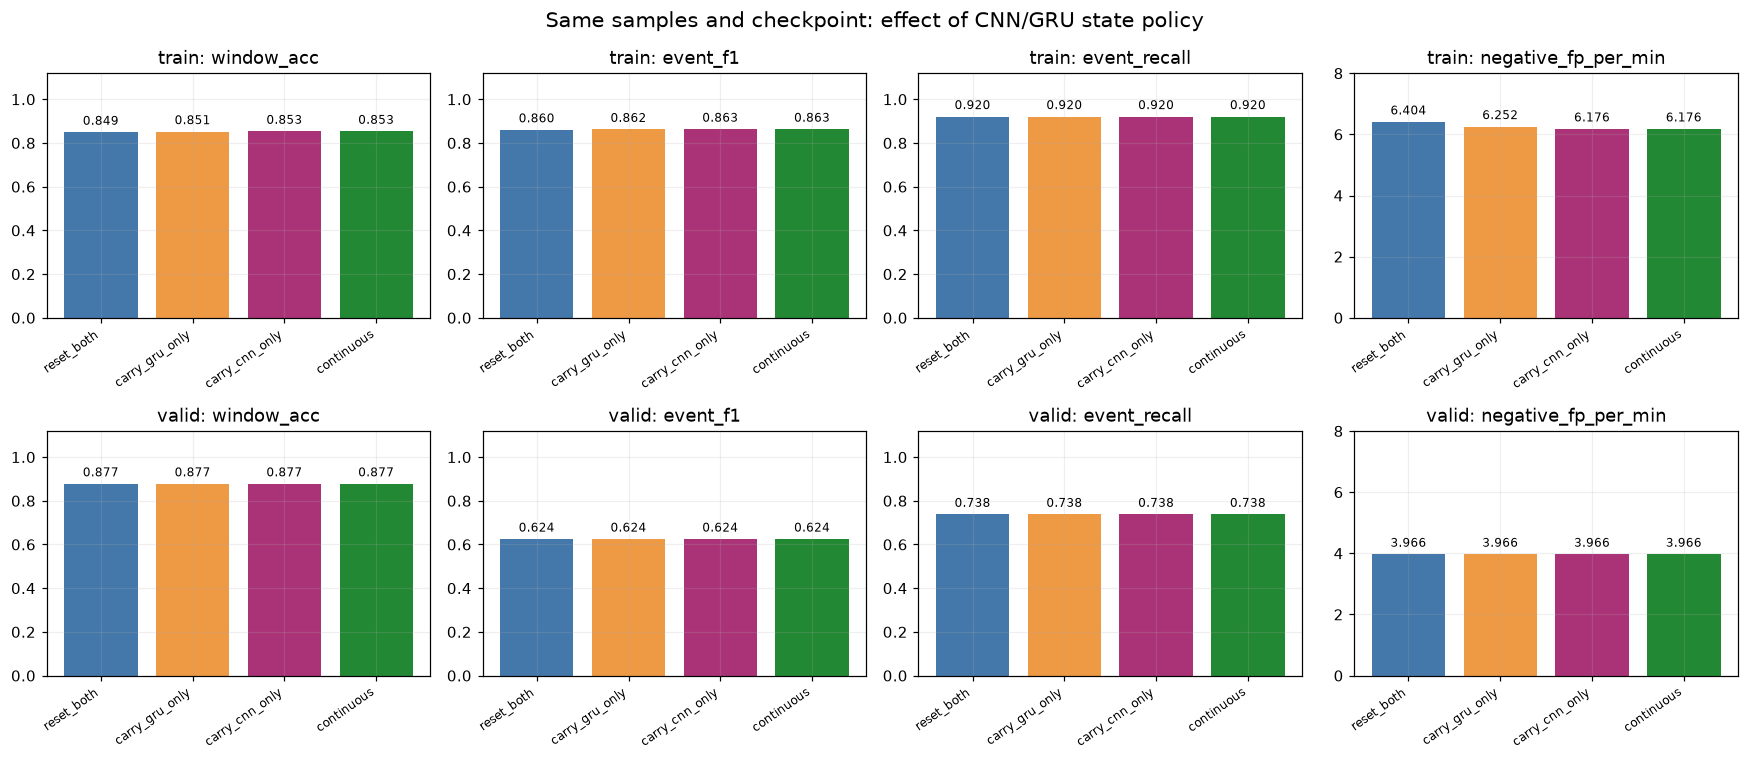

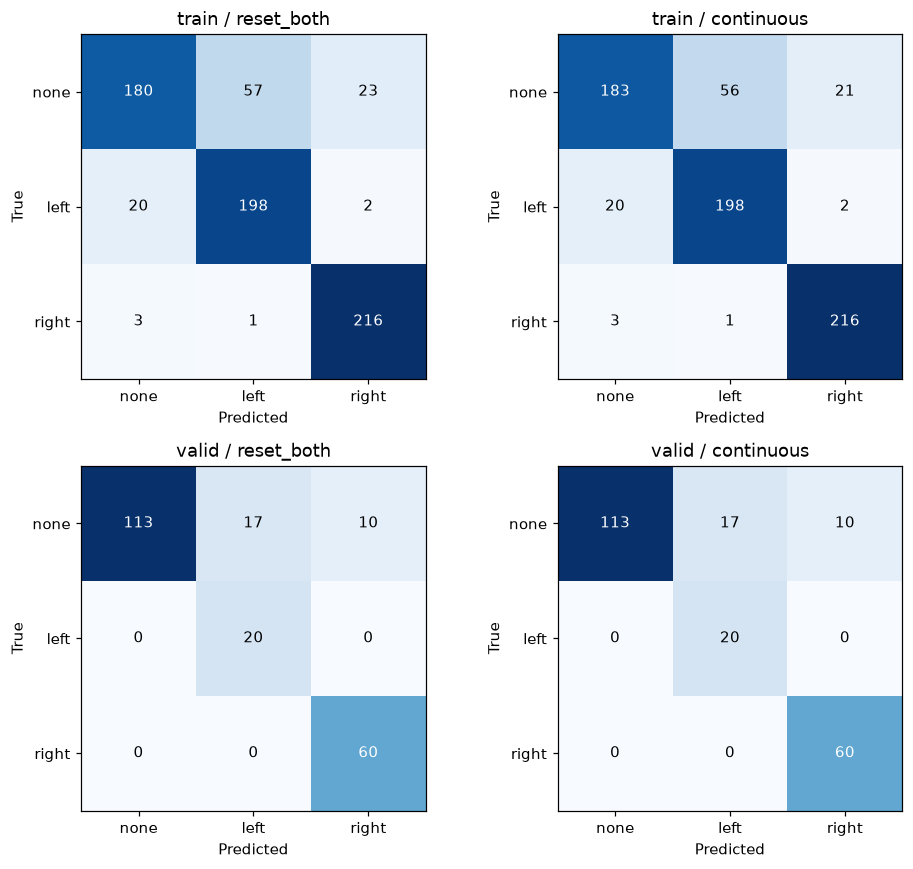

In [6]:
# Quantify probability changes, including small changes that do not flip a decision.
probability_rows = []
for split in ['train', 'valid']:
    for contrast, (before, after) in contrasts.items():
        differences, class_flips, threshold_flips = [], 0, 0
        for rec in [r for r in recordings if r.split == split]:
            p = predictions[(rec.split, rec.path.name)]['probs']
            differences.append(np.abs(p[after] - p[before]).max(axis=1))
            class_flips += int((p[after].argmax(axis=1) != p[before].argmax(axis=1)).sum())
            threshold_flips += int(((p[after][:, 1:].max(axis=1) >= settings['threshold']) !=
                                    (p[before][:, 1:].max(axis=1) >= settings['threshold'])).sum())
        d = np.concatenate(differences)
        probability_rows.append(dict(split=split, contrast=contrast, mean_max_class_delta=d.mean(),
                                     p99_max_class_delta=np.quantile(d, .99), maximum_delta=d.max(),
                                     fraction_delta_over_001=(d > .01).mean(),
                                     frame_class_flips=class_flips, frame_threshold_flips=threshold_flips))
probability_df = pd.DataFrame(probability_rows)
display(probability_df)

# Plot 1: overall metrics, with the same y scales for train and validation.
COLORS = {'reset_both': '#4477AA', 'carry_gru_only': '#EE9944',
          'carry_cnn_only': '#AA3377', 'continuous': '#228833'}
metrics_to_plot = ['window_acc', 'event_f1', 'event_recall', 'negative_fp_per_min']
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey='col')
for row, split in enumerate(['train', 'valid']):
    table = summary_df[summary_df.split.eq(split)].set_index('mode').loc[list(MODES)]
    for col, metric in enumerate(metrics_to_plot):
        ax = axes[row, col]
        bars = ax.bar(range(4), table[metric], color=list(COLORS.values()))
        ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=3)
        ax.set_xticks(range(4), list(MODES), rotation=35, ha='right', fontsize=8)
        ax.set_title(f'{split}: {metric}')
        if metric != 'negative_fp_per_min': ax.set_ylim(0, 1.12)
        else: ax.margins(y=.25)
fig.suptitle('Same samples and checkpoint: effect of CNN/GRU state policy', fontsize=14)
plt.tight_layout(); plt.show()

# Plot 2: exact side errors versus binary errors, using raw-segment window predictions.
fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for i, split in enumerate(['train', 'valid']):
    for j, mode in enumerate(['reset_both', 'continuous']):
        rows = file_df[file_df.split.eq(split) & file_df['mode'].eq(mode)]
        cm = np.array([[rows[f'cm_{t}{p}'].sum() for p in range(3)] for t in range(3)])
        ax = axes[i, j]
        ax.imshow(cm, cmap='Blues', vmin=0)
        for t in range(3):
            for p in range(3): ax.text(p, t, str(cm[t, p]), ha='center', va='center',
                                      color='white' if cm[t, p] > cm.max()/2 else 'black')
        ax.set_xticks(range(3), ['none', 'left', 'right'])
        ax.set_yticks(range(3), ['none', 'left', 'right'])
        ax.set(xlabel='Predicted', ylabel='True', title=f'{split} / {mode}')
        ax.grid(False)
plt.tight_layout(); plt.show()


## 5. Paired uncertainty and recording-level heterogeneity
Resample whole recordings **in pairs**, stratified by action, for 2,000 bootstrap replicates. Do not treat the hundreds of thousands of highly correlated frames as independent observations. Intervals are descriptive and conditional on these recordings/action proportions; validation has few positive files, and files from the same person are not independent people. They are not evidence about hours of use or unseen-user generalization.

Deltas below are `after − before`. Positive accuracy/F1/recall is better; positive false positives per minute is worse.


,split,before,after,metric,delta,ci_low,ci_high
0,train,reset_both,continuous,window_acc,0.00429,0.00143,0.00714
1,train,reset_both,continuous,event_f1,0.00275,0.00090,0.00466
2,train,reset_both,continuous,event_recall,0.00000,0.00000,0.00000
3,train,reset_both,continuous,negative_fp_per_min,-0.22873,-0.38130,-0.07622
4,train,reset_both,carry_gru_only,window_acc,0.00286,0.00000,0.00571
5,train,reset_both,carry_gru_only,event_f1,0.00183,0.00000,0.00380
6,train,reset_both,carry_gru_only,event_recall,0.00000,0.00000,0.00000
7,train,reset_both,carry_gru_only,negative_fp_per_min,-0.15248,-0.30504,0.00000
8,train,carry_cnn_only,continuous,window_acc,0.00000,0.00000,0.00000
9,train,carry_cnn_only,continuous,event_f1,0.00000,0.00000,0.00000


,split,action,mode,window_acc,event_tp,event_fp,event_fn
0,train,arbitrary,reset_both,0.700,0.0,13.0,0.0
1,train,arbitrary,carry_gru_only,0.750,0.0,11.0,0.0
2,train,arbitrary,carry_cnn_only,0.825,0.0,8.0,0.0
3,train,arbitrary,continuous,0.825,0.0,8.0,0.0
4,train,knock_twice_left,reset_both,0.900,194.0,6.0,26.0
...,...,...,...,...,...,...,...
59,valid,knock_twice_right,continuous,1.000,44.0,16.0,16.0
60,valid,knock_twice_left,reset_both,1.000,15.0,6.0,5.0
61,valid,knock_twice_left,carry_gru_only,1.000,15.0,6.0,5.0
62,valid,knock_twice_left,carry_cnn_only,1.000,15.0,6.0,5.0


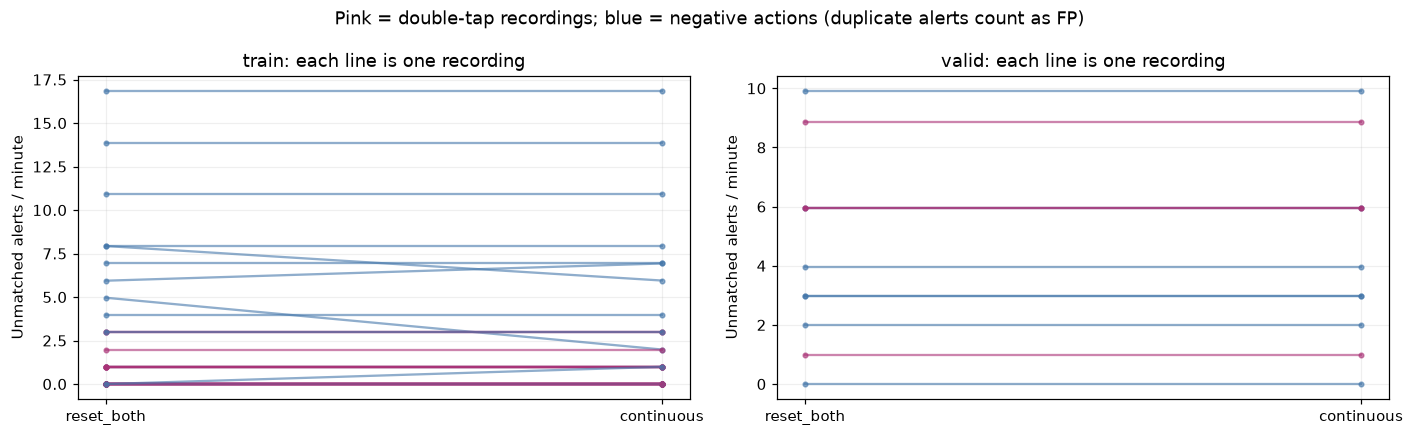

In [7]:
bootstrap_df = paired_bootstrap(file_df, draws=2000, seed=SEED)
display(bootstrap_df)
by_action_df = summarize(file_df, ('split', 'action', 'mode'))
display(by_action_df[['split', 'action', 'mode', 'window_acc', 'event_tp', 'event_fp', 'event_fn']])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, split in zip(axes, ['train', 'valid']):
    files = file_df[file_df.split.eq(split)].copy()
    files['event_fp_per_min'] = files.event_fp / files.minutes
    wide = files.pivot(index='file', columns='mode', values='event_fp_per_min')
    actions = files.drop_duplicates('file').set_index('file').action
    for file, row in wide.iterrows():
        positive = 'knock_twice' in actions[file]
        ax.plot([0, 1], [row.reset_both, row.continuous], '-o', alpha=.6,
                color='#AA3377' if positive else '#4477AA', markersize=3)
    ax.set_xticks([0, 1], ['reset_both', 'continuous'])
    ax.set(title=f'{split}: each line is one recording', ylabel='Unmatched alerts / minute')
fig.suptitle('Pink = double-tap recordings; blue = negative actions (duplicate alerts count as FP)')
plt.tight_layout(); plt.show()


## 6. Is the difference at boundaries, or does it grow through the minute?
Probability difference means the largest absolute difference among the three class probabilities for a frame. The boundary plot excludes the first segment (all modes start identically). Curves average frames within 100 ms bins and then recordings. The segment-number plots are descriptive: a trend alone does not prove hidden-state drift; repeated actions, event timing, and recording-level context can also cause it.


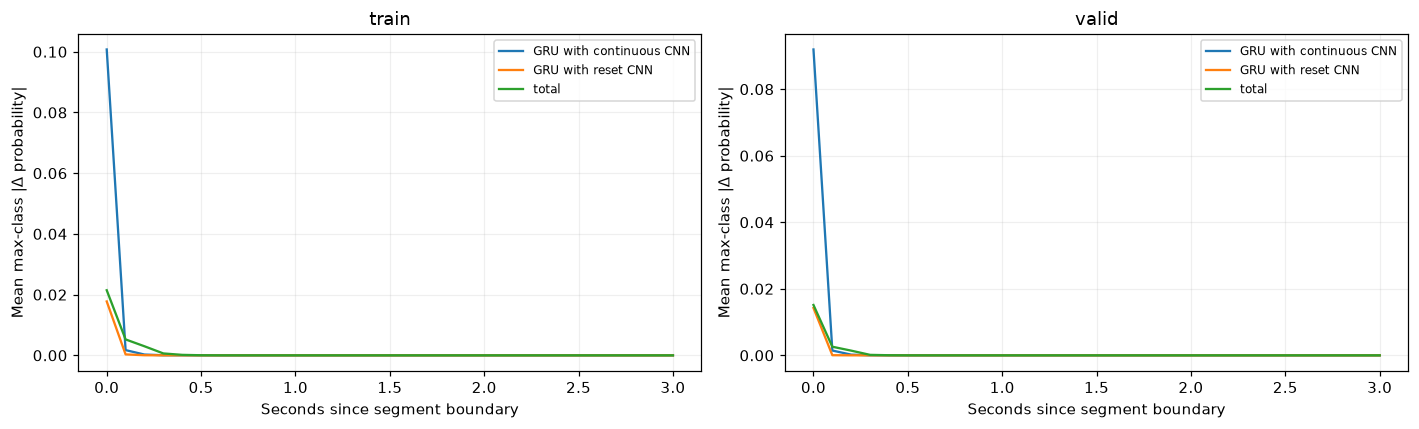

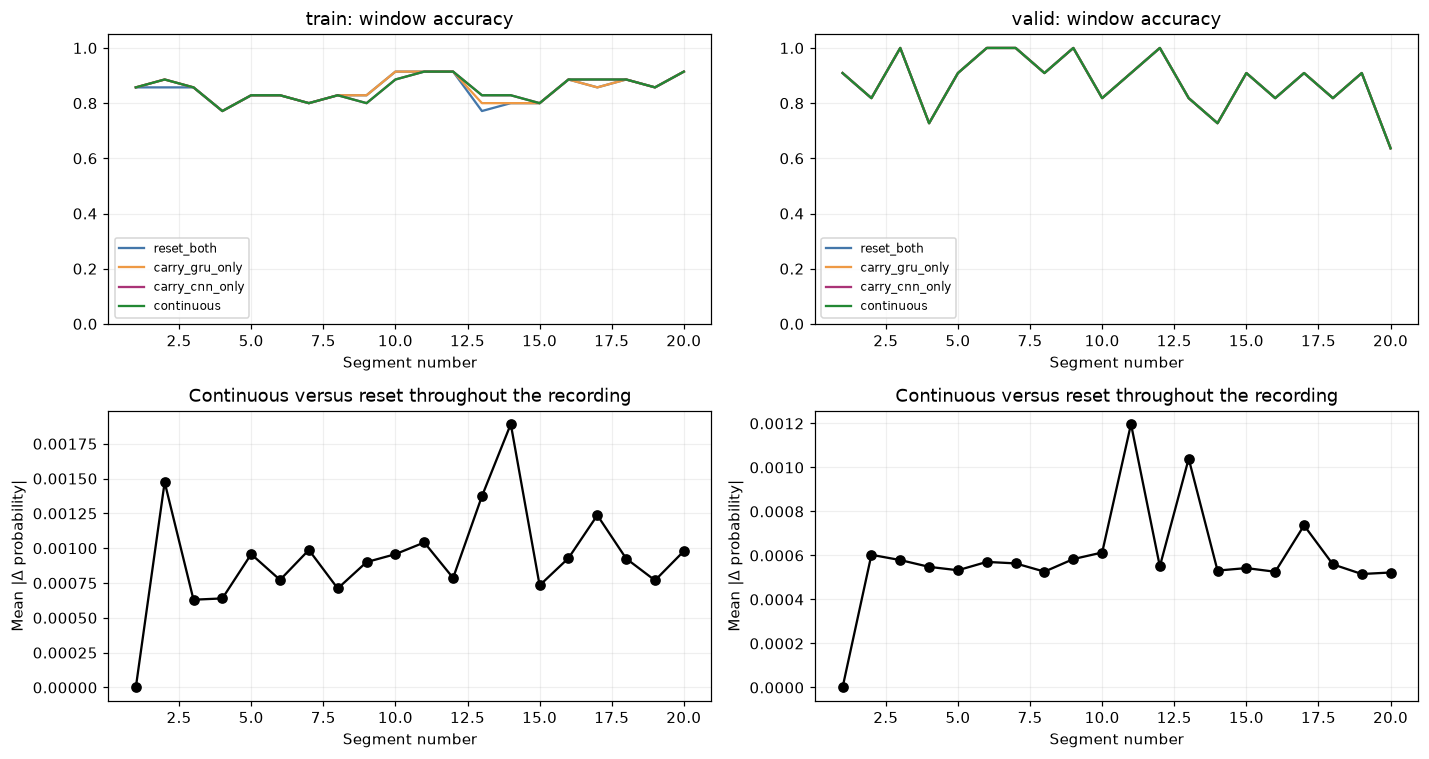

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, split in zip(axes, ['train', 'valid']):
    rows = boundary_df[boundary_df.split.eq(split) & boundary_df.segment.gt(1)]
    by_file = rows.groupby(['file', 'contrast', 'seconds_from_boundary']).mean_delta.mean().reset_index()
    for contrast, g in by_file.groupby('contrast'):
        curve = g.groupby('seconds_from_boundary').mean_delta.mean()
        ax.plot(curve.index, curve.values, label=contrast)
    ax.set(title=split, xlabel='Seconds since segment boundary', ylabel='Mean max-class |Δ probability|')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for col, split in enumerate(['train', 'valid']):
    for mode in MODES:
        rows = segment_df[segment_df.split.eq(split) & segment_df['mode'].eq(mode)]
        curve = rows.groupby('segment').correct.mean()
        axes[0, col].plot(curve.index, curve.values, label=mode, color=COLORS[mode])
    axes[0, col].set(title=f'{split}: window accuracy', ylim=(0, 1.05), xlabel='Segment number')
    axes[0, col].legend(fontsize=8)
    rows = boundary_df[boundary_df.split.eq(split) & boundary_df.contrast.eq('total')]
    curve = rows.groupby('segment').mean_delta.mean()
    axes[1, col].plot(curve.index, curve.values, 'o-', color='black')
    axes[1, col].set(xlabel='Segment number', ylabel='Mean |Δ probability|',
                     title='Continuous versus reset throughout the recording')
plt.tight_layout(); plt.show()


## 7. Full-recording traces and boundary zooms
Choose the validation positive and negative recording with the largest mean probability difference, deterministically. Also show the training negative recording with the most changed window decisions (ties broken by probability difference). These are **illustrative extreme cases**, not representative random samples; aggregate metrics above include all files. Gray dashed lines are segment boundaries, black dotted lines are annotated events. Event markers are actual model predictions, not ground-truth positions. Zoom selection finds the boundary followed by the largest change.


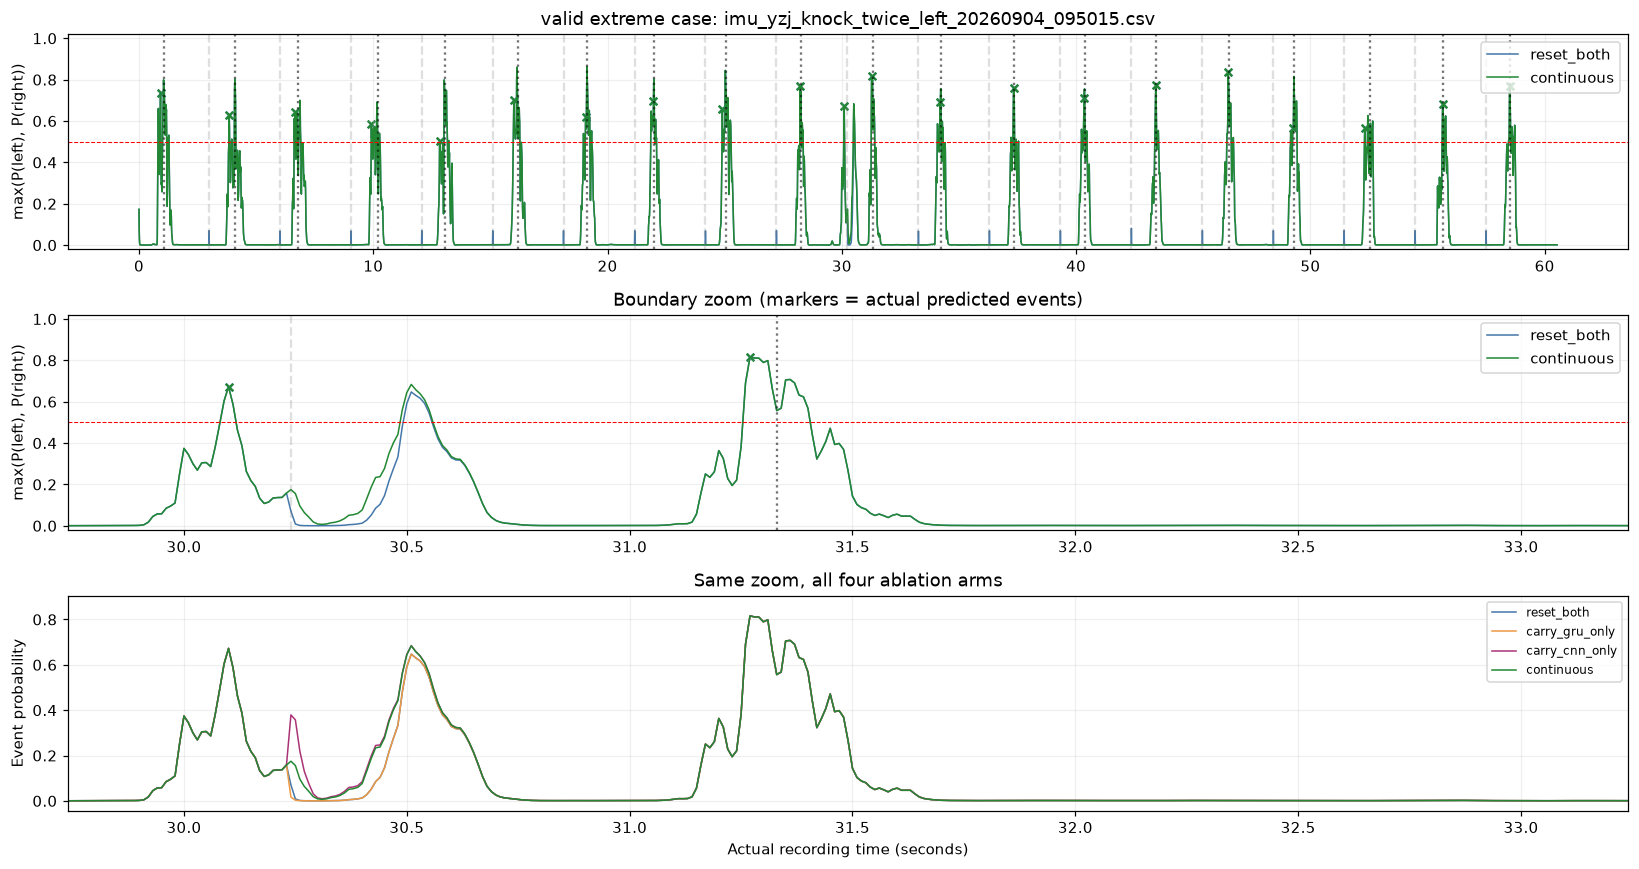

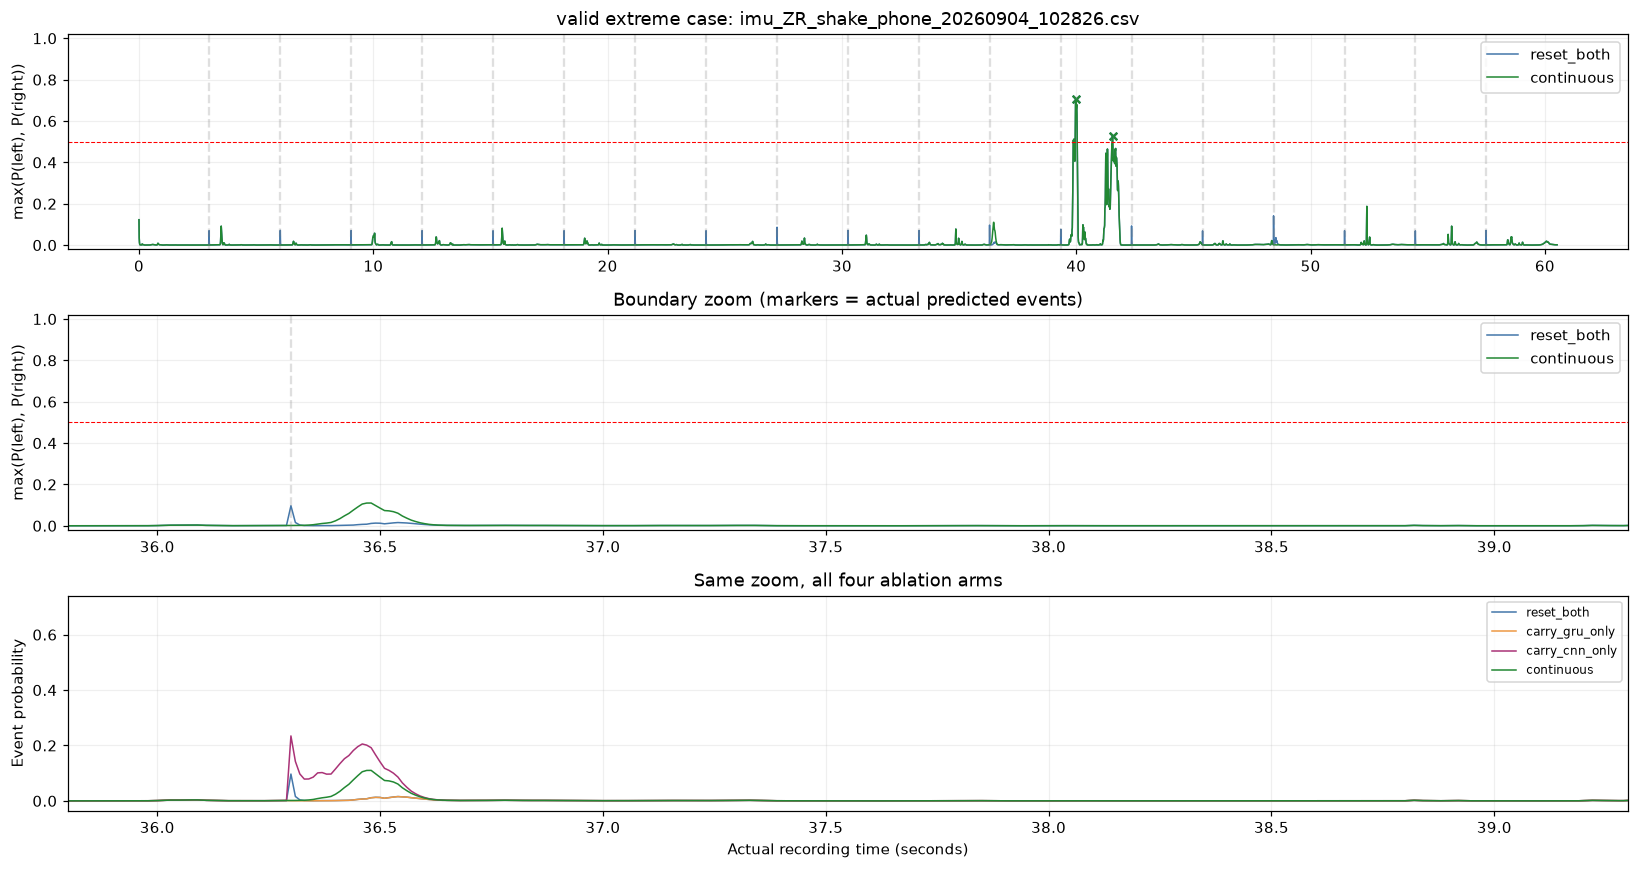

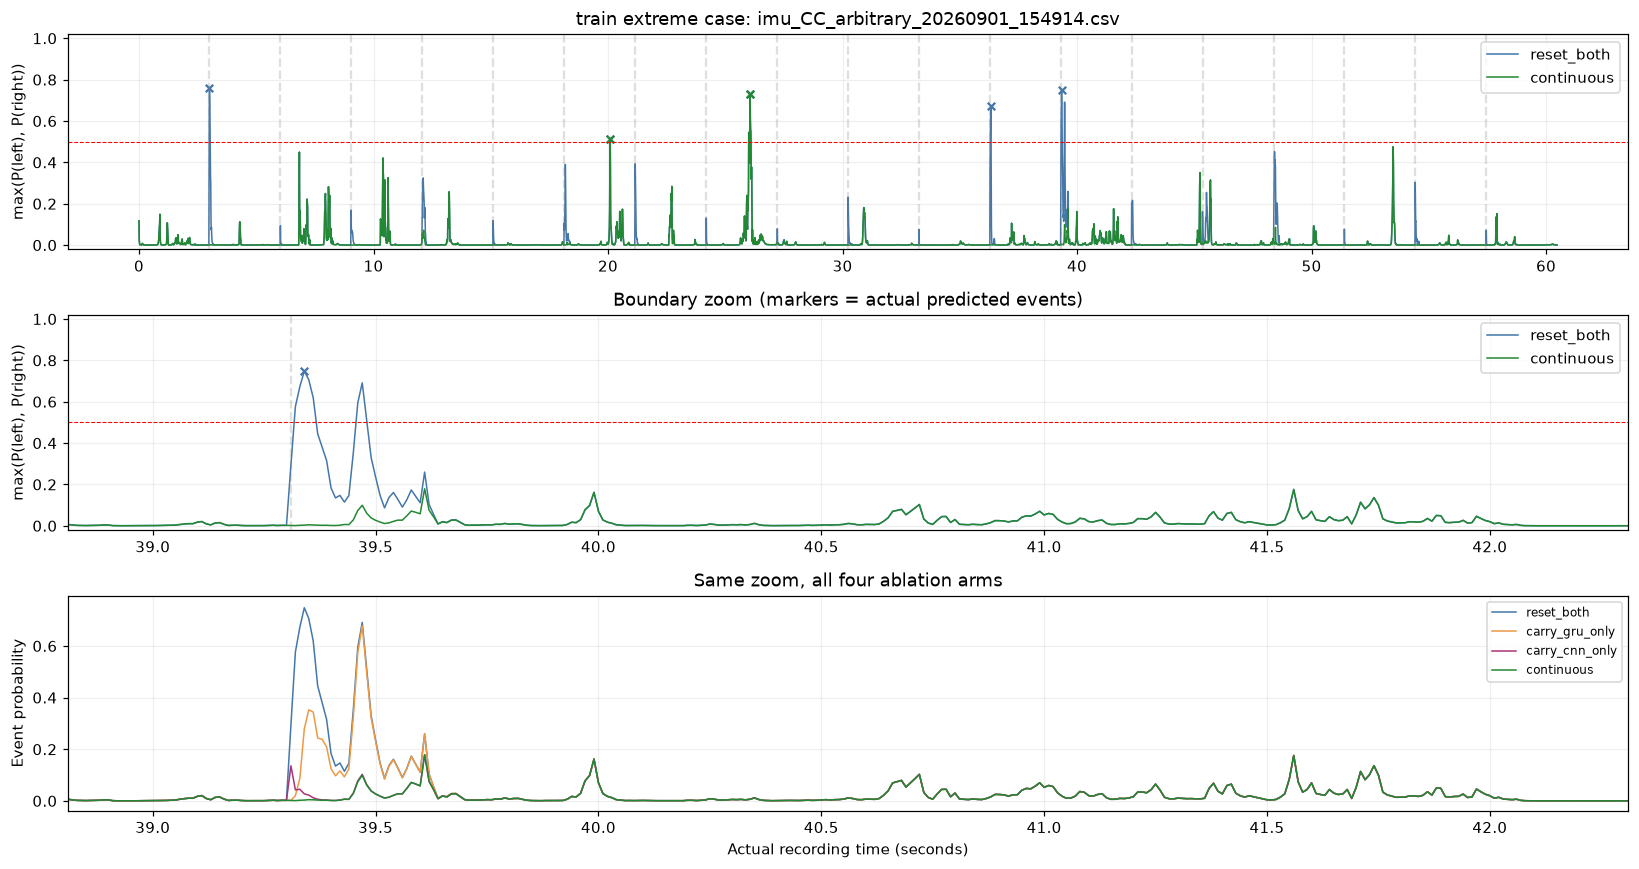

In [9]:
def probability_difference(rec):
    p = predictions[(rec.split, rec.path.name)]['probs']
    return np.abs(p['continuous'] - p['reset_both']).max(axis=1)

def changed_windows(rec):
    rows = segment_df[segment_df.split.eq(rec.split) & segment_df.file.eq(rec.path.name)]
    wide = rows.pivot(index='segment', columns='mode', values='pred')
    return int((wide.reset_both != wide.continuous).sum())

for split, positive in [('valid', True), ('valid', False), ('train', False)]:
    candidates = [r for r in recordings if r.split == split and bool(r.events) == positive]
    if not candidates: continue
    rec = max(candidates, key=lambda r: (changed_windows(r) if split == 'train' else 0,
                                         probability_difference(r).mean()))
    p = predictions[(rec.split, rec.path.name)]['probs']
    delta = probability_difference(rec)
    boundary = max([a for a, b in rec.bounds[1:]], key=lambda a: delta[a:a+100].mean())
    fig, axes = plt.subplots(3, 1, figsize=(15, 8))
    for ax in axes[:2]:
        for mode in ['reset_both', 'continuous']:
            ax.plot(rec.time, p[mode][:, 1:].max(axis=1), label=mode, color=COLORS[mode], lw=1)
            detected = event_df[event_df.split.eq(rec.split) & event_df.file.eq(rec.path.name)
                                & event_df['mode'].eq(mode)]
            frames = detected.frame.to_numpy(dtype=int)
            ax.scatter(rec.time[frames], p[mode][frames, 1:].max(axis=1),
                       color=COLORS[mode], marker='x', s=24)
        for a, _ in rec.bounds[1:]: ax.axvline(rec.time[a], color='gray', ls='--', alpha=.25)
        for frame, _ in rec.events: ax.axvline(rec.time[frame], color='black', ls=':', alpha=.55)
        ax.axhline(settings['threshold'], color='red', ls='--', lw=.7)
        ax.set(ylabel='max(P(left), P(right))', ylim=(-.02, 1.02))
        ax.legend(loc='upper right')
    axes[0].set_title(f'{split} extreme case: {rec.path.name}')
    axes[1].set_xlim(max(0, rec.time[boundary] - .5), rec.time[boundary] + 3)
    axes[1].set_title('Boundary zoom (markers = actual predicted events)')
    for mode in MODES:
        axes[2].plot(rec.time, p[mode][:, 1:].max(axis=1), label=mode, color=COLORS[mode], lw=1)
    axes[2].set(xlim=axes[1].get_xlim(), xlabel='Actual recording time (seconds)',
                ylabel='Event probability', title='Same zoom, all four ablation arms')
    axes[2].legend(fontsize=8)
    plt.tight_layout(); plt.show()


## 8. Sensitivity to threshold and temporal matching tolerance
Keep the main threshold from checkpoint metadata. The plots below vary one evaluation parameter at a time, without choosing a best setting on validation. A broad tolerance can conceal mistimed detections, so compare 50–250 ms. Neither settings nor weights are optimized here.


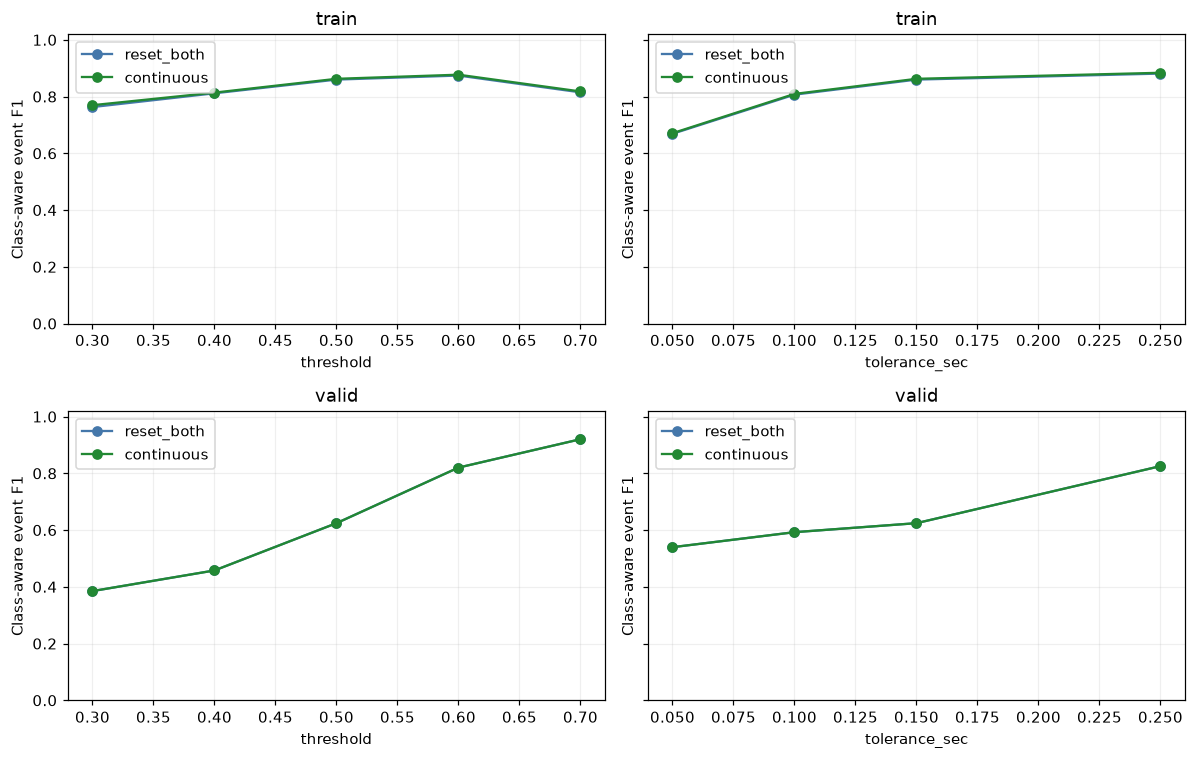

In [10]:
sensitivity_rows = []
scenarios = ([('threshold', float(t), settings['tolerance_sec']) for t in [.3, .4, .5, .6, .7]]
             + [('tolerance_sec', settings['threshold'], float(t)) for t in [.05, .10, .15, .25]])
for parameter, threshold, tolerance in scenarios:
    for rec in recordings:
        for mode in ['reset_both', 'continuous']:
            probs = predictions[(rec.split, rec.path.name)]['probs'][mode]
            counts, _ = event_counts(rec, probs, threshold, tolerance,
                                     settings['look_ahead_sec'], settings['refractory_sec'])
            sensitivity_rows.append(dict(split=rec.split, mode=mode, parameter=parameter,
                                         threshold=threshold, tolerance_sec=tolerance, **counts))
sensitivity_df = pd.DataFrame(sensitivity_rows).groupby(
    ['split', 'mode', 'parameter', 'threshold', 'tolerance_sec'], as_index=False
).sum(numeric_only=True)
sensitivity_df['event_f1'] = 2 * sensitivity_df.event_tp / (
    2 * sensitivity_df.event_tp + sensitivity_df.event_fp + sensitivity_df.event_fn
)
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharey=True)
for i, split in enumerate(['train', 'valid']):
    for j, parameter in enumerate(['threshold', 'tolerance_sec']):
        for mode in ['reset_both', 'continuous']:
            rows = sensitivity_df[sensitivity_df.split.eq(split) & sensitivity_df['mode'].eq(mode)
                                  & sensitivity_df.parameter.eq(parameter)].sort_values(parameter)
            axes[i, j].plot(rows[parameter], rows.event_f1, 'o-', label=mode, color=COLORS[mode])
        axes[i, j].set(xlabel=parameter, ylabel='Class-aware event F1', title=split, ylim=(0, 1.02))
        axes[i, j].legend()
plt.tight_layout(); plt.show()


## 9. Results, changed decisions, and reproducibility bundle
The summary below is generated from the evaluated arrays. CSV exports preserve per-file, per-segment and per-detection results; the JSON manifest fingerprints the checkpoint, all input CSVs and sparse labels, relevant code, settings and package versions. Re-run with another checkpoint by changing only `CHECKPOINT` above.


In [11]:
decision_rows, event_identity_rows = [], []
for split in ['train', 'valid']:
    segments = segment_df[segment_df.split.eq(split)]
    wide = segments.pivot(index=['file', 'segment', 'truth'], columns='mode', values='pred').reset_index()
    a, b, y = wide.reset_both, wide.continuous, wide.truth
    decision_rows.append(dict(split=split, windows=len(wide), changed=int((a != b).sum()),
                              fixed=int(((a != y) & (b == y)).sum()),
                              broken=int(((a == y) & (b != y)).sum())))
    identities = {}
    for mode in ['reset_both', 'continuous']:
        events = event_df[event_df.split.eq(split) & event_df['mode'].eq(mode)]
        identities[mode] = set(events[['file', 'frame', 'class_id']].itertuples(index=False, name=None))
    a, b = identities['reset_both'], identities['continuous']
    event_identity_rows.append(dict(split=split, identical_frame_and_class=len(a & b),
                                    only_in_reset=len(a - b), only_in_continuous=len(b - a)))
decision_df = pd.DataFrame(decision_rows)
display(decision_df)
event_identity_df = pd.DataFrame(event_identity_rows)
display(event_identity_df)
lines = ['### Observed result for `' + str(CHECKPOINT.relative_to(ROOT)) + '`']
for split in ['train', 'valid']:
    table = summary_df[summary_df.split.eq(split)].set_index('mode')
    a, b = table.loc['reset_both'], table.loc['continuous']
    lines.append(f'- **{split}**: window accuracy {a.window_acc:.2%} → {b.window_acc:.2%}; '
                 f'event F1 {a.event_f1:.3f} → {b.event_f1:.3f}; '
                 f'event TP/FP/FN {int(a.event_tp)}/{int(a.event_fp)}/{int(a.event_fn)} → '
                 f'{int(b.event_tp)}/{int(b.event_fp)}/{int(b.event_fn)}; '
                 f'negative-recording FP/min {a.negative_fp_per_min:.3f} → {b.negative_fp_per_min:.3f}.')
    c = table.loc['carry_cnn_only']
    lines.append(f'  - Holding CNN continuous, carrying GRU changes window accuracy by '
                 f'{100 * (b.window_acc-c.window_acc):+.2f} percentage points and '
                 f'event F1 by {b.event_f1-c.event_f1:+.3f}.')
lines.append('\n**Readout:** identical decision counts do not imply identical probabilities. '
             'Use the probability-difference table and GRU-only arms above. A zero bootstrap '
             'interval can occur when every observed paired recording has identical counts; '
             'it is not proof of zero effect on future recordings.')
display(Markdown('\n'.join(lines)))

tables = {'audit': audit_df, 'legacy_300_frame': legacy_df.reset_index(),
          'checkpoint_metric_comparison': metadata_comparison, 'numerical_checks': numerical_df,
          'summary': summary_df, 'per_recording': file_df, 'per_segment': segment_df,
          'predicted_events': event_df, 'bootstrap': bootstrap_df,
          'by_action': by_action_df, 'sensitivity': sensitivity_df, 'changed_decisions': decision_df,
          'probability_differences': probability_df, 'event_identity_comparison': event_identity_df}
for name, table in tables.items(): table.to_csv(OUT / f'{name}.csv', index=False)
source_paths = [ROOT / 'train.py', ROOT / 'notebooks/state_reset_analysis.py',
                *sorted((ROOT / 'tap_recognition').glob('*.py'))]
manifest = {
    'created_utc': datetime.now(timezone.utc).isoformat(),
    'checkpoint': str(CHECKPOINT.relative_to(ROOT)), 'checkpoint_sha256': checkpoint_hash_before,
    'checkpoint_epoch': checkpoint.get('epoch'), 'checkpoint_config': train_config,
    'settings': settings, 'seed': SEED, 'bootstrap_draws': 2000, 'device': 'cpu', 'threads': 1,
    'python': sys.version, 'python_executable': sys.executable, 'platform': platform.platform(),
    'packages': {p: importlib.metadata.version(p) for p in
                 ['torch', 'numpy', 'pandas', 'scipy', 'matplotlib', 'ipykernel']},
    'git_commit': subprocess.check_output(['git', 'rev-parse', 'HEAD'], cwd=ROOT, text=True).strip(),
    'git_status': subprocess.check_output(['git', 'status', '--short'], cwd=ROOT, text=True),
    'inputs': data_manifest,
    'code': [{'path': str(p.relative_to(ROOT)), 'sha256': sha256(p)} for p in source_paths],
    'results': [{'path': p.name, 'sha256': sha256(p)} for p in sorted(OUT.glob('*.csv'))],
}
notebook_path = ROOT / 'notebooks/03_state_reset_vs_continuous.ipynb'
notebook_source = [cell['source'] for cell in json.loads(notebook_path.read_text())['cells']]
manifest['notebook_source_sha256'] = hashlib.sha256(json.dumps(notebook_source).encode()).hexdigest()
(OUT / 'manifest.json').write_text(json.dumps(manifest, indent=2) + '\n')
assert sha256(CHECKPOINT) == manifest['checkpoint_sha256']
print('Saved tables and manifest to', OUT.relative_to(ROOT))


,split,windows,changed,fixed,broken
0,train,700,8,5,2
1,valid,220,0,0,0


,split,identical_frame_and_class,only_in_reset,only_in_continuous
0,train,496,6,3
1,valid,109,0,0


### Observed result for `checkpoints/best.pt`
- **train**: window accuracy 84.86% → 85.29%; event F1 0.860 → 0.863; event TP/FP/FN 405/97/35 → 405/94/35; negative-recording FP/min 6.404 → 6.176.
  - Holding CNN continuous, carrying GRU changes window accuracy by +0.00 percentage points and event F1 by +0.000.
- **valid**: window accuracy 87.73% → 87.73%; event F1 0.624 → 0.624; event TP/FP/FN 59/50/21 → 59/50/21; negative-recording FP/min 3.966 → 3.966.
  - Holding CNN continuous, carrying GRU changes window accuracy by +0.00 percentage points and event F1 by +0.000.

**Readout:** identical decision counts do not imply identical probabilities. Use the probability-difference table and GRU-only arms above. A zero bootstrap interval can occur when every observed paired recording has identical counts; it is not proof of zero effect on future recordings.

Saved tables and manifest to notebooks/results/state_reset_checkpoints_best


## Interpretation boundaries
- This tests **state-reset policy for these existing weights**, not whether stateful training would improve the model.
- A continuous/reset gap alone does not prove GRU drift. Use the GRU-only ablations and temporal plots to distinguish recurrent context from CNN boundary artifacts.
- Full recordings here contain one repeated action for about a minute. Results cannot establish behavior after hours, transitions between activities, or ordinary phone use. Train and validation also share some users; validation is not a new-user test.
- The deployed `step()` path must be corrected and separately validated. The continuous arm here is the numerically checked streaming equivalent of `forward()`, not a benchmark of that buggy path.
- Existing-window metrics can look good while event-level metrics expose duplicates or mistiming. Timing is measured from predicted peaks, not fabricated from labels.
- No threshold was selected on validation; sensitivity curves and confidence intervals describe this experiment rather than select a model.
